# 🎯 Cuaderno 04 — Regresión Logística
**Rol:** Experto en Machine Learning  
**Proyecto:** Predicción de Adicción a Redes Sociales en Estudiantes  
**Variable objetivo:** `High_Addiction_Risk` — 0 = Bajo Riesgo · 1 = Alto Riesgo (puntaje ≥ 7)

---
**Objetivo:** Clasificar si un estudiante tiene **alto riesgo de adicción**, evaluar el
modelo con métricas de clasificación e identificar las variables más determinantes para
diseñar alertas tempranas de intervención.

> 🔑 **¿Por qué Regresión Logística?**  
> La pregunta real no es "¿cuánto mide la adicción?" sino "¿este estudiante ESTÁ en riesgo?"
> La regresión logística calcula una **probabilidad** (0–100%) de ser de alto riesgo.


## 📦 Paso 1 — Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ Librerías importadas")


✅ Librerías importadas


## 📂 Paso 2 — Carga y exploración inicial del dataset

In [6]:
for ruta in ['adiccion_regresion_logistica.csv','adiccion_regresion_logistica.csv']:
    try:
        df = pd.read_csv(ruta); print(f"✅ {ruta}"); break
    except FileNotFoundError: continue
else:
    raise FileNotFoundError("❌ No se encontró el archivo. Ejecutar ETL primero.")

OBJETIVO = 'High_Addiction_Risk'
# Create High_Addiction_Risk based on Addicted_Score >= 7
df[OBJETIVO] = (df['Addicted_Score'] >= 7).astype(int)

# Compatibilidad: si está en español
if OBJETIVO not in df.columns and 'adiccion_alta_binario' in df.columns:
    df[OBJETIVO] = df['adiccion_alta_binario']

# Remove 'Addicted_Score' and the newly created 'High_Addiction_Risk' from features
FEATURES = [c for c in df.columns if c not in [OBJETIVO, 'adiccion_alta_binario', 'Addicted_Score']]

print(f"\n📐 {df.shape[0]} estudiantes × {df.shape[1]} columnas")
print(f"🎯 Objetivo: {OBJETIVO}")
for clase in [1, 0]:
    n = (df[OBJETIVO]==clase).sum()
    nombre = 'ALTO RIESGO' if clase==1 else 'Bajo riesgo'
    print(f"   Clase {clase} ({nombre}): {n} ({n/len(df)*100:.1f}%)")

✅ adiccion_regresion_logistica.csv

📐 705 estudiantes × 14 columnas
🎯 Objetivo: High_Addiction_Risk
   Clase 1 (ALTO RIESGO): 408 (57.9%)
   Clase 0 (Bajo riesgo): 297 (42.1%)


## 🔧 Paso 3 — Preprocesamiento y balance de clases

✅ Features escaladas con StandardScaler


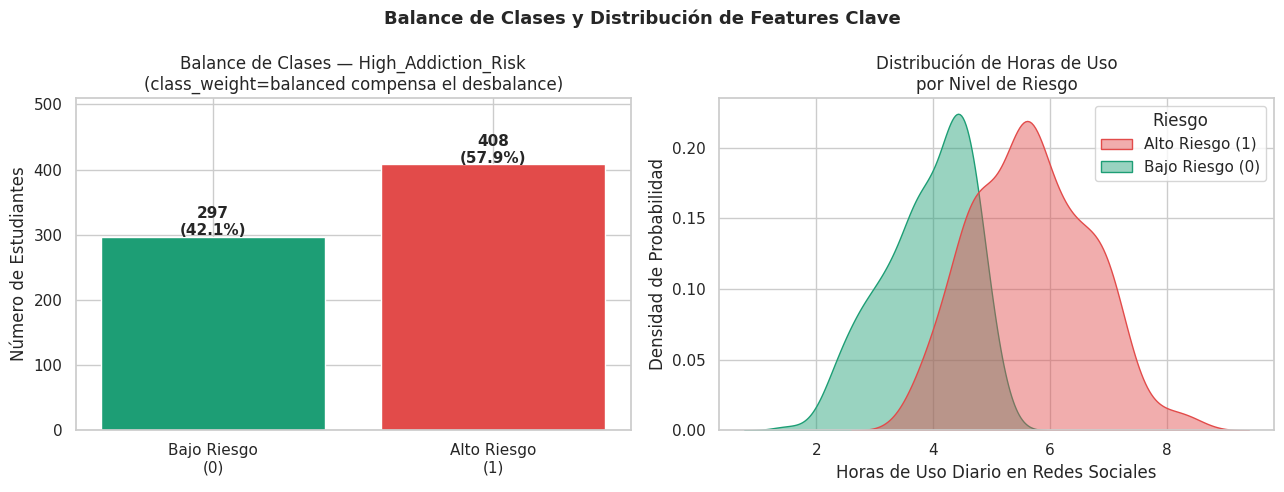

✅ Guardada: logistica_preprocesamiento.png


In [11]:
# Re-initialize FEATURES from df before one-hot encoding
initial_features_for_X = [c for c in df.columns if c not in [OBJETIVO, 'adiccion_alta_binario', 'Addicted_Score']]
X = df[initial_features_for_X].copy()
y = df[OBJETIVO].copy()

# Drop 'Student_ID' from features as it's an identifier, not a predictive feature
if 'Student_ID' in X.columns:
    X = X.drop('Student_ID', axis=1)

# Identify categorical columns for one-hot encoding
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Update the global FEATURES list to reflect the new columns after one-hot encoding
global FEATURES # Declare global to modify the variable defined in cell c53463171
FEATURES = X.columns.tolist()

scaler = StandardScaler()
X_esc = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)
print("✅ Features escaladas con StandardScaler")

# Visualizar balance de clases
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Balance de Clases y Distribución de Features Clave', fontsize=13, fontweight='bold')

ax = axes[0]
conteo = y.value_counts().sort_index()
colores_c = ['#1D9E75','#E24B4A']
bars = ax.bar(['Bajo Riesgo\n(0)','Alto Riesgo\n(1)'], conteo.values, color=colores_c, edgecolor='white')
for bar, cnt in zip(bars, conteo.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{cnt}\n({cnt/len(y)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Balance de Clases — High_Addiction_Risk\n(class_weight=balanced compensa el desbalance)')
ax.set_ylabel('Número de Estudiantes')
ax.set_ylim(0, conteo.max()*1.25)

# KDE de horas de uso por clase
ax = axes[1]
df_plot = df.copy()
df_plot['Riesgo'] = df_plot[OBJETIVO].map({0:'Bajo Riesgo (0)',1:'Alto Riesgo (1)'})
sns.kdeplot(data=df_plot, x='Avg_Daily_Usage_Hours', hue='Riesgo', fill=True, alpha=0.45,
            palette={'Bajo Riesgo (0)':'#1D9E75','Alto Riesgo (1)':'#E24B4A'}, ax=ax)
ax.set_title('Distribución de Horas de Uso\npor Nivel de Riesgo')
ax.set_xlabel('Horas de Uso Diario en Redes Sociales')
ax.set_ylabel('Densidad de Probabilidad')

plt.tight_layout()
plt.savefig('logistica_preprocesamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: logistica_preprocesamiento.png")

## 🔍 Paso 4 — Análisis exploratorio: ¿qué separa las clases?

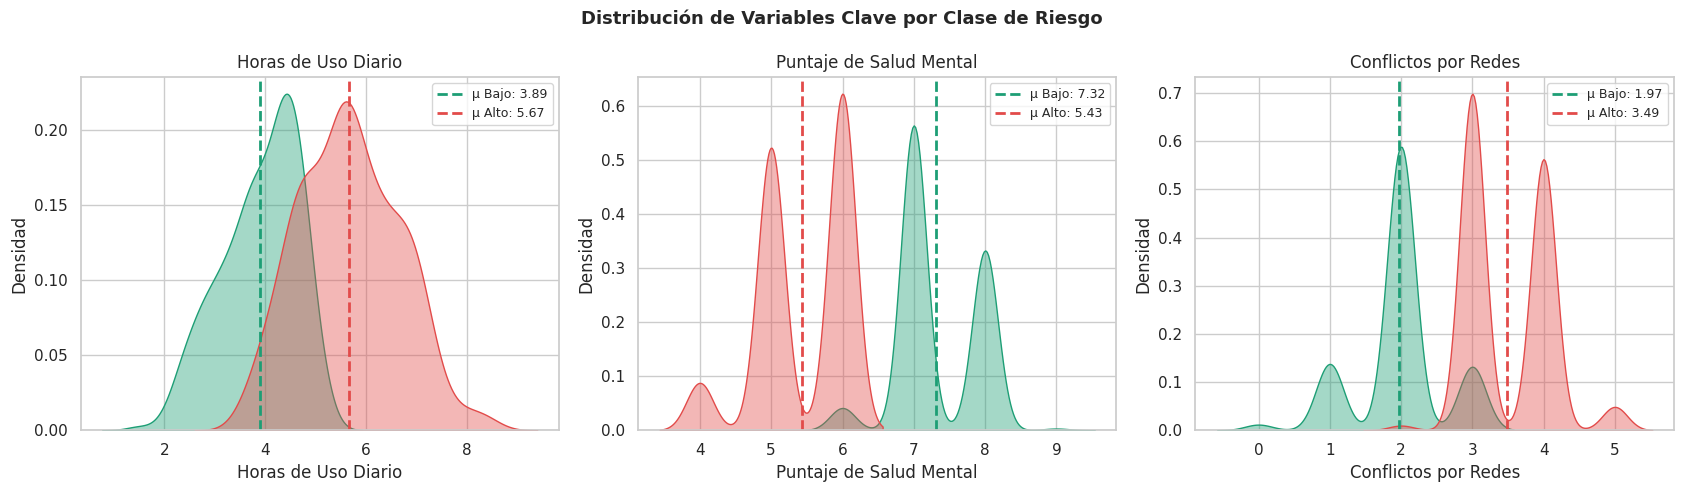

✅ Guardada: logistica_separacion_clases.png

📊 Diferencia entre grupos:
  Horas de Uso Diario           : Bajo=3.89 | Alto=5.67 | Δ=+1.77  ↑ más alto en alto riesgo
  Puntaje de Salud Mental       : Bajo=7.32 | Alto=5.43 | Δ=-1.88  ↓ más bajo en alto riesgo
  Conflictos por Redes          : Bajo=1.97 | Alto=3.49 | Δ=+1.53  ↑ más alto en alto riesgo


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Distribución de Variables Clave por Clase de Riesgo', fontsize=13, fontweight='bold')

features_clave = ['Avg_Daily_Usage_Hours','Mental_Health_Score','Conflicts_Over_Social_Media']
nombres_clave  = ['Horas de Uso Diario','Puntaje de Salud Mental','Conflictos por Redes']
colores_kde    = {'Bajo Riesgo (0)':'#1D9E75','Alto Riesgo (1)':'#E24B4A'}

for ax, feat, nombre in zip(axes, features_clave, nombres_clave):
    df_p = df[[feat,OBJETIVO]].copy()
    df_p['Riesgo'] = df_p[OBJETIVO].map({0:'Bajo Riesgo (0)',1:'Alto Riesgo (1)'})
    sns.kdeplot(data=df_p, x=feat, hue='Riesgo', fill=True, alpha=0.4,
                palette=colores_kde, ax=ax)
    # Marcar medias de cada grupo
    m0 = df[df[OBJETIVO]==0][feat].mean()
    m1 = df[df[OBJETIVO]==1][feat].mean()
    ax.axvline(m0, color='#1D9E75', ls='--', lw=2, label=f'μ Bajo: {m0:.2f}')
    ax.axvline(m1, color='#E24B4A', ls='--', lw=2, label=f'μ Alto: {m1:.2f}')
    ax.set_title(f'{nombre}')
    ax.set_xlabel(nombre)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('logistica_separacion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: logistica_separacion_clases.png")
print("\n📊 Diferencia entre grupos:")
for feat, nombre in zip(features_clave, nombres_clave):
    m0 = df[df[OBJETIVO]==0][feat].mean()
    m1 = df[df[OBJETIVO]==1][feat].mean()
    delta = m1-m0
    dir_ = '↑ más alto en alto riesgo' if delta>0 else '↓ más bajo en alto riesgo'
    print(f"  {nombre:<30}: Bajo={m0:.2f} | Alto={m1:.2f} | Δ={delta:+.2f}  {dir_}")

## ✂️ Paso 5 — División estratificada del dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_esc, y, test_size=0.2, random_state=42, stratify=y)

print("✅ División estratificada (stratify=y garantiza misma proporción de clases):")
print(f"   Entrenamiento : {X_train.shape[0]} muestras")
print(f"   Prueba        : {X_test.shape[0]} muestras")
print(f"\n   Proporción en entrenamiento:")
for c in [0,1]:
    n = (y_train==c).sum()
    print(f"     Clase {c}: {n} ({n/len(y_train)*100:.1f}%)")


✅ División estratificada (stratify=y garantiza misma proporción de clases):
   Entrenamiento : 564 muestras
   Prueba        : 141 muestras

   Proporción en entrenamiento:
     Clase 0: 238 (42.2%)
     Clase 1: 326 (57.8%)


## 🤖 Paso 6 — Entrenamiento del modelo

In [15]:
modelo = LogisticRegression(
    class_weight='balanced',   # compensa desbalance 57%/43%
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
modelo.fit(X_train, y_train)
print("✅ Regresión Logística entrenada")
print(f"   class_weight='balanced' — ajusta los pesos para no ignorar la clase minoritaria")

coefs = pd.DataFrame({
    'Feature':                FEATURES,
    'Coef. (log-odds)':       modelo.coef_[0],
    'Odds Ratio (exp(β))':    np.exp(modelo.coef_[0]),
    '|Coef|':                 np.abs(modelo.coef_[0]),
    'Efecto sobre riesgo':    ['↑ Aumenta riesgo' if b>0 else '↓ Reduce riesgo' for b in modelo.coef_[0]]
}).sort_values('|Coef|', ascending=False).reset_index(drop=True)
print("\n📊 Coeficientes del modelo:")
display(coefs.round(4))


✅ Regresión Logística entrenada
   class_weight='balanced' — ajusta los pesos para no ignorar la clase minoritaria

📊 Coeficientes del modelo:


,Feature,Coef. (log-odds),Odds Ratio (exp(β)),|Coef|,Efecto sobre riesgo
0,Mental_Health_Score,-3.0990,0.0451,3.0990,↓ Reduce riesgo
1,Affects_Academic_Performance_Yes,1.4382,4.2130,1.4382,↑ Aumenta riesgo
2,Sleep_Hours_Per_Night,-1.0541,0.3485,1.0541,↓ Reduce riesgo
3,Avg_Daily_Usage_Hours,0.8023,2.2307,0.8023,↑ Aumenta riesgo
4,Conflicts_Over_Social_Media,0.6665,1.9473,0.6665,↑ Aumenta riesgo
...,...,...,...,...,...
126,Country_Bhutan,0.0012,1.0012,0.0012,↑ Aumenta riesgo
127,Country_Ecuador,0.0009,1.0009,0.0009,↑ Aumenta riesgo
128,Country_Trinidad,0.0009,1.0009,0.0009,↑ Aumenta riesgo
129,Country_Latvia,0.0007,1.0007,0.0007,↑ Aumenta riesgo


## 🔮 Paso 7 — Predicciones sobre el conjunto de prueba

In [16]:
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:,1]

print("📋 Primeras 20 predicciones con probabilidad:")
cmp = pd.DataFrame({
    'Real':            y_test.values[:20],
    'Predicho':        y_pred[:20],
    'Prob. Alto (%)':  (y_proba[:20]*100).round(1),
    'Correcto':        (y_test.values[:20]==y_pred[:20])
})
display(cmp.style.applymap(lambda v: 'color:green;font-weight:bold' if v==True
                           else ('color:red' if v==False else ''), subset=['Correcto']))


📋 Primeras 20 predicciones con probabilidad:


,Real,Predicho,Prob. Alto (%),Correcto
0,0,0,0.000000,True
1,1,1,87.600000,True
2,0,0,4.500000,True
3,1,1,100.000000,True
4,1,1,100.000000,True
5,1,1,99.800000,True
6,1,1,99.500000,True
7,1,1,99.200000,True
8,0,0,0.200000,True
9,0,0,0.000000,True


## 📏 Paso 8 — Métricas de evaluación: Precisión, Recall y más

In [17]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)
cv   = cross_val_score(modelo, X_esc, y, cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring='f1')

print("═"*62)
print("  MÉTRICAS — REGRESIÓN LOGÍSTICA (High_Addiction_Risk)")
print("═"*62)
print(f"  Exactitud  (Accuracy)  : {acc:.4f}  → {acc*100:.1f}% de clasificaciones correctas")
print(f"  Precisión  (Precision) : {prec:.4f}  → De los 'Alto Riesgo' predichos, {prec*100:.1f}% son reales")
print(f"  Sensibilidad (Recall)  : {rec:.4f}  → Detecta el {rec*100:.1f}% de los casos reales de alto riesgo")
print(f"  F1-Score               : {f1:.4f}  → Balance precisión-sensibilidad")
print(f"  AUC-ROC                : {auc:.4f}  → {'Bueno ✅' if auc>=0.75 else 'Aceptable'}")
print(f"  F1 Validación Cruzada  : {cv.mean():.4f} ± {cv.std():.4f}")
print("═"*62)
print(f"\n  ⚠️  NOTA SOBRE RECALL EN PREVENCIÓN:")
print(f"  En salud mental, preferimos ALTA SENSIBILIDAD (Recall).")
print(f"  Es mejor identificar de más (falso positivo) que dejar sin")
print(f"  detectar un estudiante en riesgo real (falso negativo).")
print()
print("📋 Reporte completo:")
print(classification_report(y_test, y_pred,
      target_names=['Bajo Riesgo (0)','Alto Riesgo (1)']))


══════════════════════════════════════════════════════════════
  MÉTRICAS — REGRESIÓN LOGÍSTICA (High_Addiction_Risk)
══════════════════════════════════════════════════════════════
  Exactitud  (Accuracy)  : 0.9929  → 99.3% de clasificaciones correctas
  Precisión  (Precision) : 0.9880  → De los 'Alto Riesgo' predichos, 98.8% son reales
  Sensibilidad (Recall)  : 1.0000  → Detecta el 100.0% de los casos reales de alto riesgo
  F1-Score               : 0.9939  → Balance precisión-sensibilidad
  AUC-ROC                : 0.9983  → Bueno ✅
  F1 Validación Cruzada  : 0.9975 ± 0.0030
══════════════════════════════════════════════════════════════

  ⚠️  NOTA SOBRE RECALL EN PREVENCIÓN:
  En salud mental, preferimos ALTA SENSIBILIDAD (Recall).
  Es mejor identificar de más (falso positivo) que dejar sin
  detectar un estudiante en riesgo real (falso negativo).

📋 Reporte completo:
                 precision    recall  f1-score   support

Bajo Riesgo (0)       1.00      0.98      0.99        59

## 📉 Paso 9 — Visualizaciones: Matriz de Confusión, ROC e Importancia

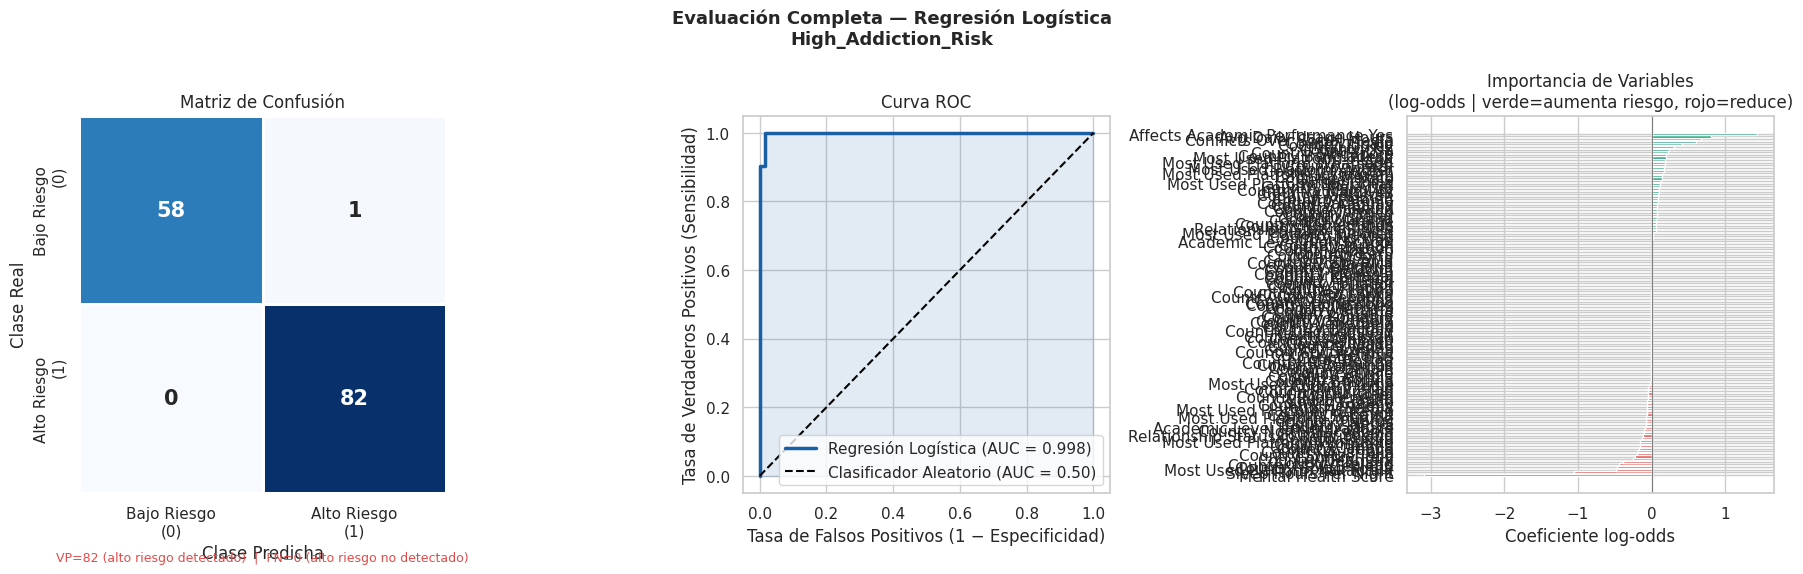

✅ Guardada: logistica_evaluacion.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluación Completa — Regresión Logística\nHigh_Addiction_Risk',
             fontsize=13, fontweight='bold')

# A) Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
etq_cm = ['Bajo Riesgo\n(0)','Alto Riesgo\n(1)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etq_cm, yticklabels=etq_cm,
            linewidths=2, ax=axes[0], cbar=False,
            annot_kws={'size':15,'weight':'bold'})
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Clase Predicha')
axes[0].set_ylabel('Clase Real')
axes[0].text(0.5,-0.18,
    f'VP={tp} (alto riesgo detectado)  |  FN={fn} (alto riesgo no detectado)',
    ha='center', transform=axes[0].transAxes, fontsize=9, color='#E24B4A')

# B) Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#185FA5', lw=2.5,
             label=f'Regresión Logística (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Clasificador Aleatorio (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#185FA5')
axes[1].set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')

# C) Importancia de variables (coeficientes log-odds)
coefs_sorted = coefs.sort_values('Coef. (log-odds)')
colores_c = ['#1D9E75' if v>0 else '#E24B4A' for v in coefs_sorted['Coef. (log-odds)']]
axes[2].barh(coefs_sorted['Feature'].str.replace('_',' ').str.title(),
             coefs_sorted['Coef. (log-odds)'], color=colores_c, edgecolor='white')
axes[2].axvline(0, color='gray', lw=0.8)
axes[2].set_title('Importancia de Variables\n(log-odds | verde=aumenta riesgo, rojo=reduce)')
axes[2].set_xlabel('Coeficiente log-odds')

plt.tight_layout()
plt.savefig('logistica_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: logistica_evaluacion.png")


## 📝 Paso 10 — Conclusiones e implicaciones para programas de prevención

In [21]:
top3_riesgo   = coefs[coefs['Coef. (log-odds)']>0].nlargest(3,'|Coef|')
top3_protec   = coefs[coefs['Coef. (log-odds)']<0].nlargest(3,'|Coef|')

# Create a mapping for feature names to their Spanish translations
feature_name_mapping = {
    'Affects_Academic_Performance_Yes': 'Afecta_Rendimiento_Academico_Sí',
    'Avg_Daily_Usage_Hours': 'Horas_Uso_Diario_Promedio',
    'Conflicts_Over_Social_Media': 'Conflictos_Por_Redes_Sociales',
    'Mental_Health_Score': 'Puntaje_Salud_Mental',
    'Sleep_Hours_Per_Night': 'Horas_Sueño_Por_Noche',
    'Most_Used_Platform_KakaoTalk': 'Plataforma_Más_Usada_KakaoTalk'
}

# Apply the mapping to the 'Feature' column for display
top3_riesgo['Feature_ES'] = top3_riesgo['Feature'].replace(feature_name_mapping)
top3_protec['Feature_ES'] = top3_protec['Feature'].replace(feature_name_mapping)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║   CONCLUSIONES — REGRESIÓN LOGÍSTICA (High_Addiction_Risk)       ║
╚══════════════════════════════════════════════════════════════════╝

RENDIMIENTO DEL MODELO:
  Exactitud   : {acc*100:.1f}% de clasificaciones correctas
  AUC-ROC     : {auc:.3f} → el modelo discrimina correctamente en el {auc*100:.0f}% de casos
  F1-Score    : {f1:.3f} → balance sólido entre Precisión y Sensibilidad

FACTORES QUE AUMENTAN EL RIESGO (coef. positivos):
""")
for _, r in top3_riesgo.iterrows():
    print(f"  ↑  {r['Feature_ES']:<32} OR = {r['Odds Ratio (exp(β))']:.3f}")

print("\nFACTORES PROTECTORES (coef. negativos):")
for _, r in top3_protec.iterrows():
    print(f"  ↓  {r['Feature_ES']:<32} OR = {r['Odds Ratio (exp(β))']:.3f}")

print(f"""
INTERPRETACIÓN DE ODDS RATIOS:
  OR > 1 → ese factor aumenta la probabilidad de alto riesgo
  OR < 1 → ese factor reduce la probabilidad de alto riesgo
  Ejemplo: OR=1.5 para horas_uso_diario significa que un estudiante
  con 1 desv. estándar más de uso tiene 50% más probabilidad de riesgo alto.

RECOMENDACIONES PARA PROGRAMAS DE PREVENCIÓN PERSONALIZADOS:
  1. Sistema de alerta temprana: usar este modelo para calcular la
     probabilidad de riesgo de cada estudiante automáticamente
  2. Intervención prioritaria: estudiantesccon Prob. Alto Riesgo > 70%
  3. Talleres focalizados en los top 3 factores de riesgo identificados
  4. Fortalecer factores protectores (variables con OR < 1) para reducir riesgo

FALSE NEGATIVES ({fn} casos):
  Son estudiantes en riesgo real que el modelo NO detectó.
  En prevención de salud mental, estos son los casos más críticos.
  → Revisar umbral de clasificación si se prioriza Sensibilidad (Recall).
""")


╔══════════════════════════════════════════════════════════════════╗
║   CONCLUSIONES — REGRESIÓN LOGÍSTICA (High_Addiction_Risk)       ║
╚══════════════════════════════════════════════════════════════════╝

RENDIMIENTO DEL MODELO:
  Exactitud   : 99.3% de clasificaciones correctas
  AUC-ROC     : 0.998 → el modelo discrimina correctamente en el 100% de casos
  F1-Score    : 0.994 → balance sólido entre Precisión y Sensibilidad

FACTORES QUE AUMENTAN EL RIESGO (coef. positivos):

  ↑  Afecta_Rendimiento_Academico_Sí  OR = 4.213
  ↑  Horas_Uso_Diario_Promedio        OR = 2.231
  ↑  Conflictos_Por_Redes_Sociales    OR = 1.947

FACTORES PROTECTORES (coef. negativos):
  ↓  Puntaje_Salud_Mental             OR = 0.045
  ↓  Horas_Sueño_Por_Noche            OR = 0.349
  ↓  Plataforma_Más_Usada_KakaoTalk   OR = 0.614

INTERPRETACIÓN DE ODDS RATIOS:
  OR > 1 → ese factor aumenta la probabilidad de alto riesgo
  OR < 1 → ese factor reduce la probabilidad de alto riesgo
  Ejemplo: OR=1.5 para hor